# Satellite Land-Cover Classification with a Custom CNN (PyTorch)

A from-scratch convolutional neural network that classifies 64x64 RGB satellite image patches into 10 land-cover classes (EuroSAT-style: residential, industrial, agricultural, and natural terrain). Built with PyTorch `Dataset`/`DataLoader`, trained with early stopping and LR scheduling, and evaluated with a full classification report and confusion matrix.

**Result:** 94.1% validation accuracy across 10 balanced classes.


In [1]:
# Setup & reproducibility

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Single global seed used everywhere randomness occurs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Select compute device (CUDA > MPS > CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")
print(f"Using device: {device}")

Using device: cuda


In [2]:
%matplotlib inline

In [4]:

# Working directory setup

PROJECT_DIR = ""
if PROJECT_DIR:
    os.chdir(PROJECT_DIR)

print(f"Current working directory: {os.getcwd()}")

# Fail early with a clear message if the data folders are not reachable
for required in ("data", "public_test_data"):
    if not os.path.isdir(required):
        print(f"WARNING: folder '{required}' not found in {os.getcwd()}. "
              f"Set PROJECT_DIR above to the folder that contains it.")

# Create the assets directory tree used for plots and model weights
os.makedirs("assets/plots", exist_ok=True)
os.makedirs("assets/weights", exist_ok=True)

Current working directory: /content


## Data Handling and Pre-Processing

In [5]:
# Fixed class order
CLASS_ORDER = ['HerbaceousVegetation', 'AnnualCrop', 'Residential', 'Pasture',
               'Industrial', 'River', 'Highway', 'Forest', 'PermanentCrop', 'SeaLake']


def preprocess(data_folder: str) -> tuple[pd.DataFrame, dict]:
    """Build a labeled DataFrame of all images plus a {class_name: label} dict.

    Returns
    -------
    df : pd.DataFrame with columns ['folder', 'file_name', 'label']
    label_dict : dict mapping class name -> numeric label
    """
    label_dict = {cls: i for i, cls in enumerate(CLASS_ORDER)}
    rows = []
    for cls in sorted(os.listdir(data_folder)):
        cls_path = os.path.join(data_folder, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in sorted(os.listdir(cls_path)):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                rows.append({"folder": cls_path,
                             "file_name": fname,
                             "label": label_dict[cls]})

    df = pd.DataFrame(rows).sample(frac=1, random_state=SEED).reset_index(drop=True)
    return df, label_dict


dataset, label_dict = preprocess("data")
idx2class = {v: k for k, v in label_dict.items()}   # reverse mapping (label -> name)
dataset.head()

,folder,file_name,label
0,data/PermanentCrop,PermanentCrop_1553.jpg,8
1,data/Industrial,Industrial_315.jpg,4
2,data/Forest,Forest_2924.jpg,7
3,data/Industrial,Industrial_428.jpg,4
4,data/Industrial,Industrial_2201.jpg,4


In [6]:
# Sanity check
print(f"Length of dataset: {len(dataset)}")
print("Label dictionary:", label_dict)

Length of dataset: 10000
Label dictionary: {'HerbaceousVegetation': 0, 'AnnualCrop': 1, 'Residential': 2, 'Pasture': 3, 'Industrial': 4, 'River': 5, 'Highway': 6, 'Forest': 7, 'PermanentCrop': 8, 'SeaLake': 9}


### Train / Validation split
I use an 80/20 stratified split so every class is represented proportionally in both sets. The split is seeded for reproducibility.

In [7]:
train_df, val_df = train_test_split(
    dataset,
    test_size=0.2,            # 20% held out for validation
    stratify=dataset["label"], # keep class proportions in both sets
    random_state=SEED,        # reproducible split
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
# Verify the stratification kept classes balanced
print("\nClass counts in training set:")
print(train_df["label"].map(idx2class).value_counts().sort_index())

Training samples:   8000
Validation samples: 2000

Class counts in training set:
label
AnnualCrop              800
Forest                  800
HerbaceousVegetation    800
Highway                 800
Industrial              800
Pasture                 800
PermanentCrop           800
Residential             800
River                   800
SeaLake                 800
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

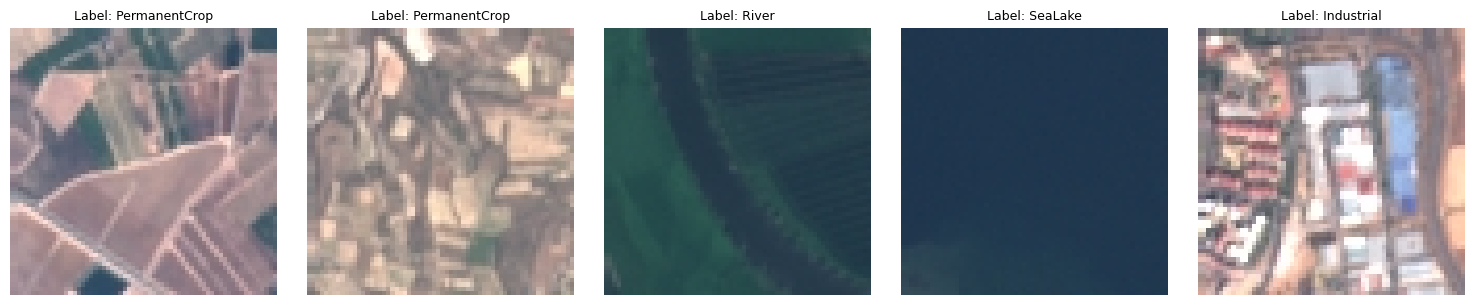

In [8]:
def show_samples(df: pd.DataFrame, num_samples: int = 5) -> None:
    """Display a horizontal grid of `num_samples` random images with their class labels.
    The figure is shown inline and saved to assets/plots/random_samples.png.
    """
    sample = df.sample(num_samples, random_state=SEED)
    fig, axes = plt.subplots(1, num_samples, figsize=(3 * num_samples, 3))
    for ax, (_, row) in zip(np.atleast_1d(axes), sample.iterrows()):
        img = Image.open(os.path.join(row["folder"], row["file_name"])).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"Label: {idx2class[row['label']]}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("assets/plots/random_samples.png", dpi=120, bbox_inches="tight")
    plt.show()


show_samples(train_df, num_samples=5)

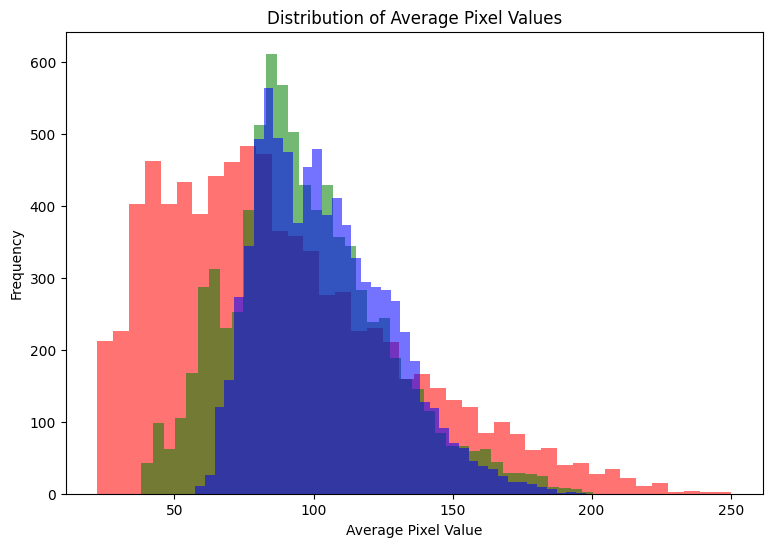

In [9]:
def average_pixel_plot(df: pd.DataFrame) -> None:
    """Overlay the per-channel (R/G/B) histograms of average pixel values across the set.
    Shown inline and saved to assets/plots/average_pixel_distribution.png.
    """
    channel_means = {0: [], 1: [], 2: []}
    for _, row in df.iterrows():
        arr = np.asarray(Image.open(os.path.join(row["folder"], row["file_name"]))
                         .convert("RGB"), dtype=np.float32)
        for ch in range(3):
            channel_means[ch].append(arr[..., ch].mean())

    plt.figure(figsize=(9, 6))
    for ch, colour in zip(range(3), ["red", "green", "blue"]):
        plt.hist(channel_means[ch], bins=40, alpha=0.55, color=colour)
    plt.title("Distribution of Average Pixel Values")
    plt.xlabel("Average Pixel Value")
    plt.ylabel("Frequency")
    plt.savefig("assets/plots/average_pixel_distribution.png", dpi=120, bbox_inches="tight")
    plt.show()


average_pixel_plot(train_df)

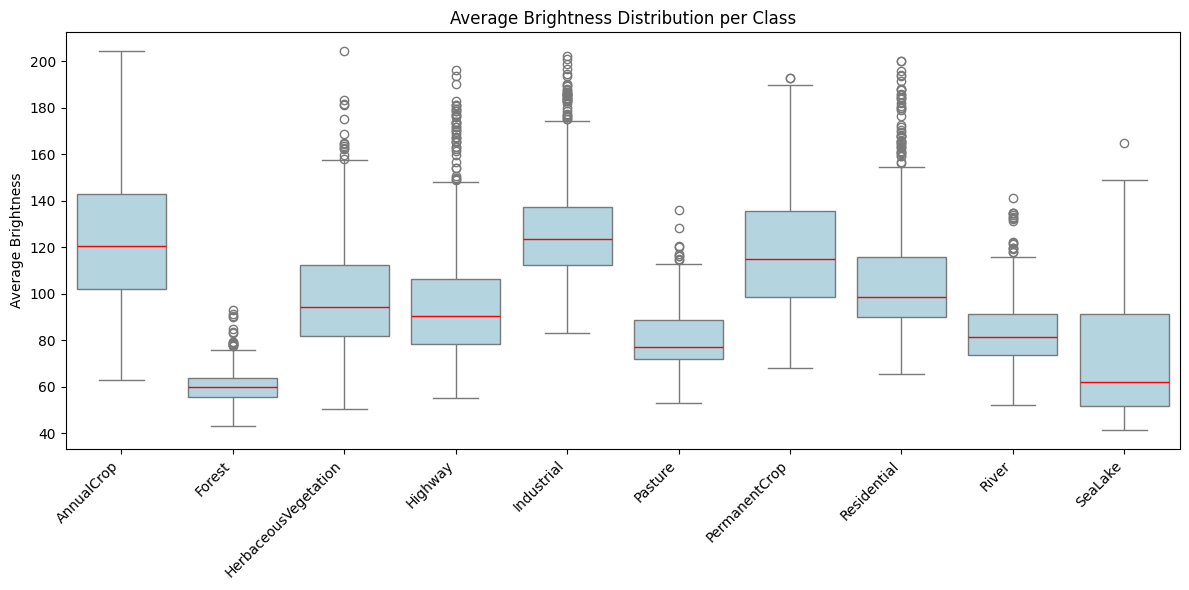

In [10]:
def average_brightness_per_class(df: pd.DataFrame) -> None:
    """Boxplot of mean brightness (average over all three channels) grouped by class.
    Shown inline and saved to assets/plots/average_brightness.png.
    """
    records = []
    for _, row in df.iterrows():
        arr = np.asarray(Image.open(os.path.join(row["folder"], row["file_name"]))
                         .convert("RGB"), dtype=np.float32)
        records.append({"class": idx2class[row["label"]], "brightness": arr.mean()})
    bdf = pd.DataFrame(records)

    plt.figure(figsize=(12, 6))
    order = sorted(bdf["class"].unique())
    sns.boxplot(data=bdf, x="class", y="brightness", order=order,
                color="lightblue", medianprops={"color": "red"})
    plt.title("Average Brightness Distribution per Class")
    plt.ylabel("Average Brightness")
    plt.xlabel("")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("assets/plots/average_brightness.png", dpi=120, bbox_inches="tight")
    plt.show()


average_brightness_per_class(train_df)

## CNN Implementation and Training

### Dataset class


In [11]:
# Per-channel normalisation statistics
MEAN = [0.3444, 0.3803, 0.4078]
STD = [0.2037, 0.1366, 0.1148]

# Augmentation pipeline for training
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])


eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])


class SatelliteDataset(Dataset):
    """Loads satellite images from a DataFrame (folder, file_name, [label])."""

    def __init__(self, df: pd.DataFrame, transform, has_labels: bool = True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(row["folder"], row["file_name"])).convert("RGB")
        img = self.transform(img)
        if self.has_labels:
            return img, int(row["label"])
        return img, row["file_name"]

### Data Loaders


In [12]:
BATCH_SIZE = 64
NUM_WORKERS = 0

train_loader = DataLoader(
    SatelliteDataset(train_df, train_transform),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    SatelliteDataset(val_df, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 125 | Val batches: 32


### Model Architecture


In [13]:
class SatelliteCNN(nn.Module):
    """Custom CNN for 64x64 RGB -> 10-class terrain classification."""

    def __init__(self, num_classes: int = 10):
        super().__init__()

        def conv_block(in_ch, out_ch, stride=1):
            # Conv -> BatchNorm -> ReLU
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        self.features = nn.Sequential(
            conv_block(3, 32, stride=2),     # 64 -> 32
            conv_block(32, 64), nn.MaxPool2d(2),    # 32 -> 16
            conv_block(64, 128), nn.MaxPool2d(2),   # 16 -> 8
            conv_block(128, 256), nn.MaxPool2d(2),  # 8 -> 4
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # -> (B, 256, 1, 1)
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = SatelliteCNN(num_classes=10).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTrainable parameters: {n_params:,}")

SatelliteCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Batch

### Training Loop


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2)


def run_epoch(loader, training: bool):
    """Run one epoch; return (mean_loss, accuracy)."""
    model.train() if training else model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if training:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if training:
                loss.backward()
                optimizer.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return loss_sum / total, correct / total

In [15]:
EPOCHS = 45
PATIENCE = 8
WEIGHTS_PATH = "assets/weights/best_model.pth"
HISTORY_PATH = "assets/history.csv"
FORCE_RETRAIN = False   # set True to always retrain from scratch

if (not FORCE_RETRAIN) and os.path.exists(WEIGHTS_PATH) and os.path.exists(HISTORY_PATH):
    # Reuse the trained checkpoint -> fast notebook re-runs
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
    history = pd.read_csv(HISTORY_PATH).to_dict(orient="list")
    best_val_acc = max(history["val_acc"])
    print(f"Loaded existing checkpoint (best val acc = {best_val_acc:.4f}). "
          f"Set FORCE_RETRAIN=True to retrain.")
else:
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, epochs_no_improve = 0.0, 0
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(train_loader, training=True)
        va_loss, va_acc = run_epoch(val_loader, training=False)
        scheduler.step(va_acc)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        print(f"Epoch {epoch:02d} | "
              f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.3f} acc {va_acc:.4f}")

        # Save best model & apply early stopping
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), WEIGHTS_PATH)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch}.")
                break

    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)
    # Reload the best checkpoint for evaluation
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))

print(f"Best validation accuracy: {best_val_acc:.4f}")

Epoch 01 | train loss 1.281 acc 0.542 | val loss 0.924 acc 0.6480
Epoch 02 | train loss 0.956 acc 0.664 | val loss 0.759 acc 0.7280
Epoch 03 | train loss 0.817 acc 0.708 | val loss 0.704 acc 0.7510
Epoch 04 | train loss 0.764 acc 0.735 | val loss 0.703 acc 0.7500
Epoch 05 | train loss 0.713 acc 0.741 | val loss 0.625 acc 0.7755
Epoch 06 | train loss 0.682 acc 0.759 | val loss 0.551 acc 0.7970
Epoch 07 | train loss 0.636 acc 0.774 | val loss 0.585 acc 0.8095
Epoch 08 | train loss 0.611 acc 0.783 | val loss 0.476 acc 0.8430
Epoch 09 | train loss 0.593 acc 0.788 | val loss 0.546 acc 0.8260
Epoch 10 | train loss 0.571 acc 0.807 | val loss 0.454 acc 0.8520
Epoch 11 | train loss 0.529 acc 0.814 | val loss 0.465 acc 0.8380
Epoch 12 | train loss 0.530 acc 0.817 | val loss 0.514 acc 0.8190
Epoch 13 | train loss 0.490 acc 0.831 | val loss 0.352 acc 0.8920
Epoch 14 | train loss 0.468 acc 0.840 | val loss 0.437 acc 0.8580
Epoch 15 | train loss 0.438 acc 0.848 | val loss 0.693 acc 0.7960
Epoch 16 |

## Model Evaluation

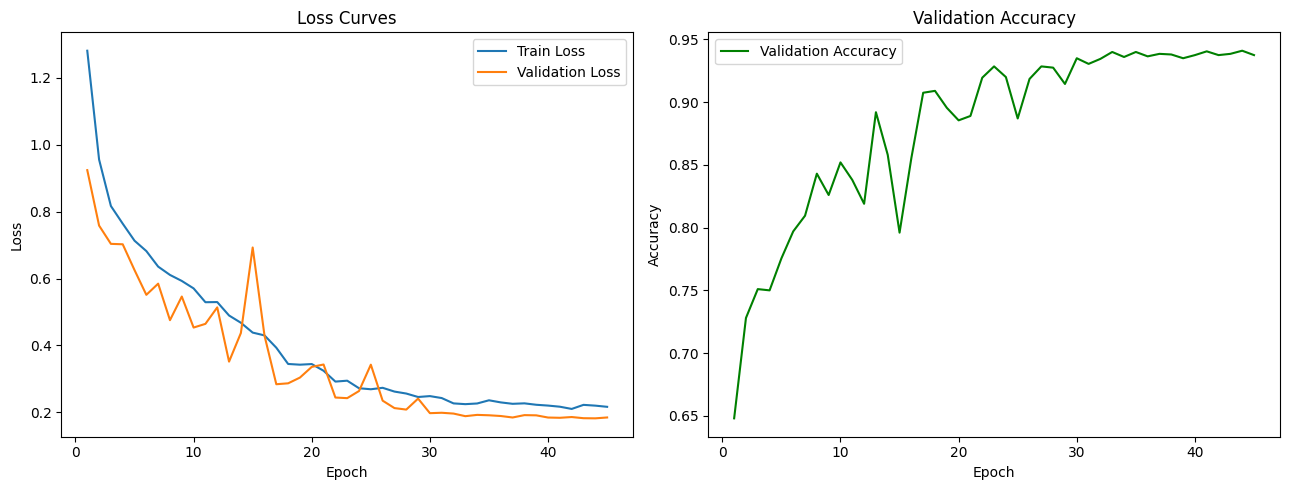

In [16]:
def plot_training_curves(history: dict) -> None:
    """Loss curves (train+val) and validation-accuracy curve, side by side."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))

    ax[0].plot(epochs, history["train_loss"], label="Train Loss")
    ax[0].plot(epochs, history["val_loss"], label="Validation Loss")
    ax[0].set_title("Loss Curves"); ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss"); ax[0].legend()

    ax[1].plot(epochs, history["val_acc"], color="green", label="Validation Accuracy")
    ax[1].set_title("Validation Accuracy"); ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy"); ax[1].legend()

    plt.tight_layout()
    plt.savefig("assets/plots/training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()


plot_training_curves(history)

In [17]:
@torch.no_grad()
def get_predictions(loader):
    """Return (true_labels, predicted_labels) numpy arrays for a labelled loader."""
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        out = model(x.to(device))
        y_pred.append(out.argmax(1).cpu().numpy())
        y_true.append(y.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


val_true, val_pred = get_predictions(val_loader)
print(f"Validation accuracy: {(val_true == val_pred).mean():.4f}\n")
print(classification_report(val_true, val_pred,
                            target_names=[idx2class[i] for i in range(10)]))

Validation accuracy: 0.9410

                      precision    recall  f1-score   support

HerbaceousVegetation       0.93      0.87      0.90       200
          AnnualCrop       0.91      0.91      0.91       200
         Residential       0.96      0.98      0.97       200
             Pasture       0.90      0.94      0.92       200
          Industrial       0.97      0.97      0.97       200
               River       0.92      0.91      0.91       200
             Highway       0.92      0.94      0.93       200
              Forest       0.99      0.96      0.98       200
       PermanentCrop       0.91      0.93      0.92       200
             SeaLake       0.99      0.98      0.99       200

            accuracy                           0.94      2000
           macro avg       0.94      0.94      0.94      2000
        weighted avg       0.94      0.94      0.94      2000



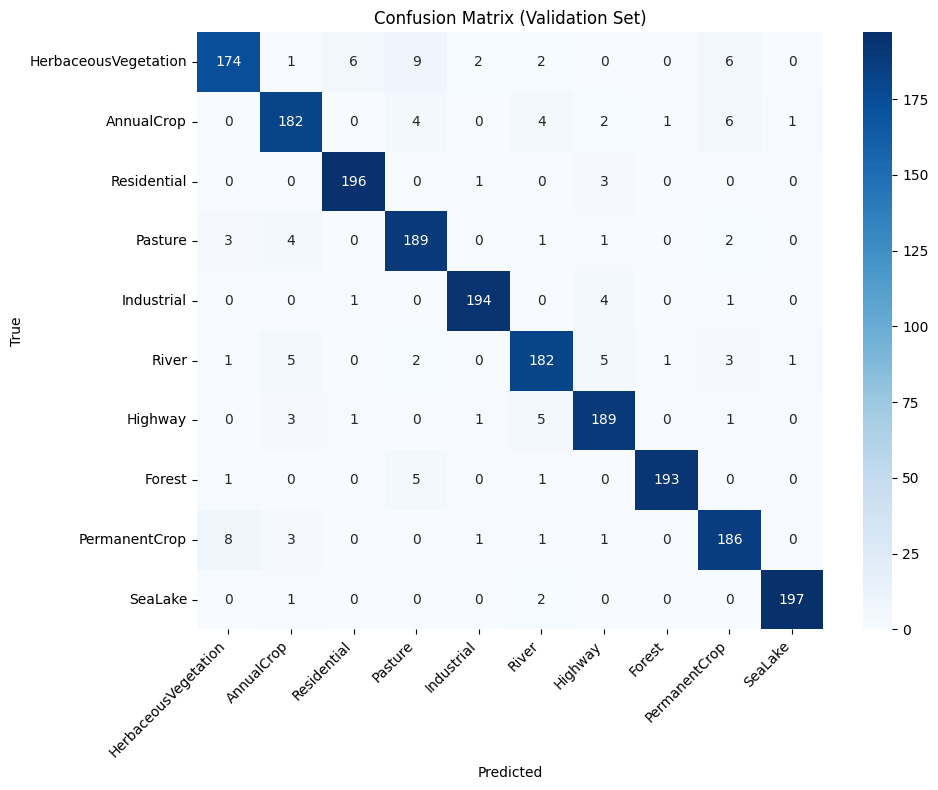

In [18]:
def plot_confusion_matrix(y_true, y_pred) -> None:
    """Annotated confusion matrix on the validation set."""
    cm = confusion_matrix(y_true, y_pred)
    names = [idx2class[i] for i in range(10)]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=names, yticklabels=names)
    plt.title("Confusion Matrix (Validation Set)")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig("assets/plots/confusion_matrix.png", dpi=120, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(val_true, val_pred)

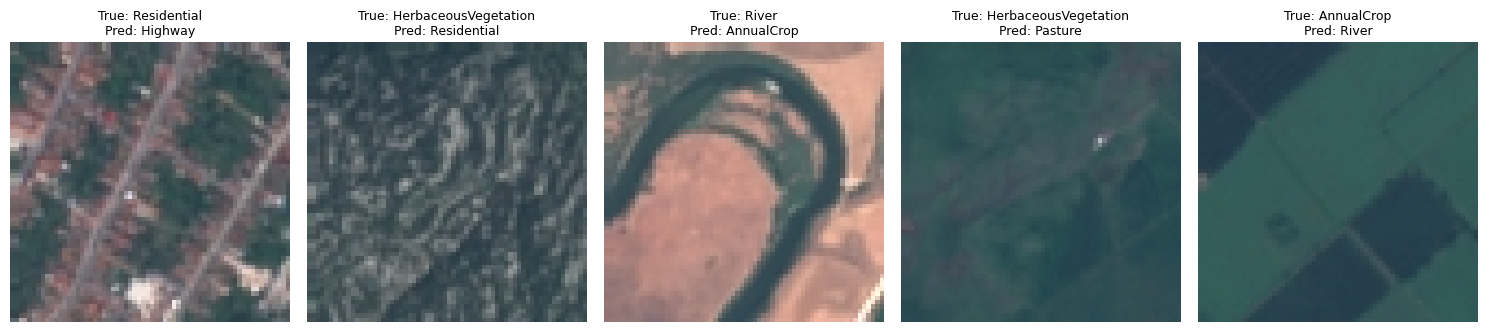

In [19]:
def plot_misclassified_samples(df, y_true, y_pred, num_samples: int = 5) -> None:
    """Show up to `num_samples` misclassified validation images with true + predicted labels."""
    wrong = np.where(y_true != y_pred)[0][:num_samples]
    fig, axes = plt.subplots(1, len(wrong), figsize=(3 * len(wrong), 3.2))
    for ax, idx in zip(np.atleast_1d(axes), wrong):
        row = df.iloc[idx]
        img = Image.open(os.path.join(row["folder"], row["file_name"])).convert("RGB")
        ax.imshow(img); ax.axis("off")
        ax.set_title(f"True: {idx2class[y_true[idx]]}\nPred: {idx2class[y_pred[idx]]}",
                     fontsize=9)
    plt.tight_layout()
    plt.savefig("assets/plots/misclassified_samples.png", dpi=120, bbox_inches="tight")
    plt.show()


plot_misclassified_samples(val_df, val_true, val_pred, num_samples=5)

### Test Set


In [20]:
def preprocess_test(data_folder: str) -> pd.DataFrame:
    """Build a (folder, file_name) DataFrame for the flat test directory."""
    files = sorted([f for f in os.listdir(data_folder)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    return pd.DataFrame({"folder": data_folder, "file_name": files})


test_df = preprocess_test("public_test_data")
print(f"Test images: {len(test_df)}")
test_df.head()

Test images: 1980


,folder,file_name
0,public_test_data,1001.jpg
1,public_test_data,1002.jpg
2,public_test_data,1008.jpg
3,public_test_data,101.jpg
4,public_test_data,1034.jpg


In [21]:
test_loader = DataLoader(
    SatelliteDataset(test_df, eval_transform, has_labels=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
)


@torch.no_grad()
def predict_test(loader):
    """Return (file_names, predicted_label_indices) for an unlabelled loader."""
    model.eval()
    names, preds = [], []
    for x, fnames in loader:
        out = model(x.to(device))
        preds.append(out.argmax(1).cpu().numpy())
        names.extend(fnames)
    return names, np.concatenate(preds)


test_names, test_preds = predict_test(test_loader)
print(f"Predicted {len(test_preds)} test images.")

Predicted 1980 test images.


In [22]:
submission = pd.DataFrame({
    "file_name": test_names,
    "predicted_class": [idx2class[p] for p in test_preds],
})
submission.to_csv("submission.csv", index=False, header=False)

print("Saved submission.csv")
print("\nPredicted class distribution:")
print(submission["predicted_class"].value_counts())
submission.head(10)

Saved submission.csv

Predicted class distribution:
predicted_class
HerbaceousVegetation    301
PermanentCrop           214
Highway                 201
Pasture                 200
SeaLake                 196
Residential             181
Forest                  177
River                   176
Industrial              174
AnnualCrop              160
Name: count, dtype: int64


,file_name,predicted_class
0,1001.jpg,HerbaceousVegetation
1,1002.jpg,Residential
2,1008.jpg,PermanentCrop
3,101.jpg,Highway
4,1034.jpg,HerbaceousVegetation
5,1042.jpg,AnnualCrop
6,1046.jpg,PermanentCrop
7,1049.jpg,AnnualCrop
8,1056.jpg,PermanentCrop
9,1066.jpg,Pasture
